In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("rent_acled_with_lags.csv")

df["month"] = pd.to_datetime(df["month"])

df = df.dropna(subset=["середня_ціна_грн"]).copy()

monthly = (
    df.groupby("month", as_index=False)["середня_ціна_грн"]
    .mean()
    .sort_values("month")
)

monthly["log_rent"] = np.log(monthly["середня_ціна_грн"])

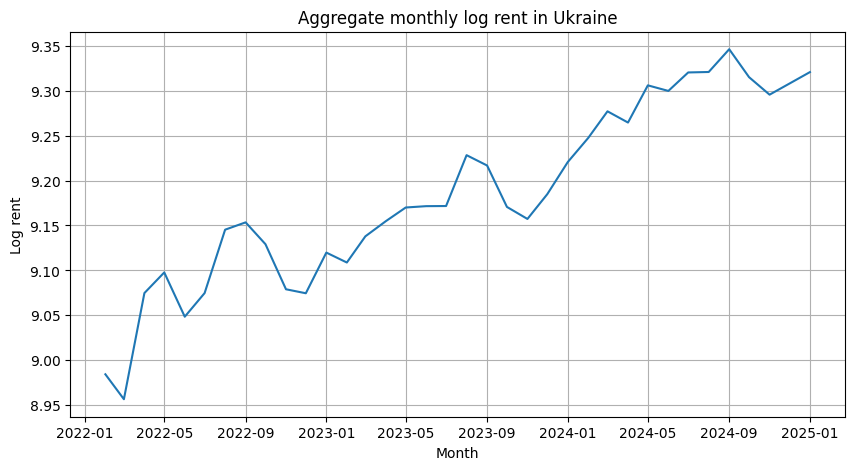

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["log_rent"])
plt.title("Aggregate monthly log rent in Ukraine")
plt.xlabel("Month")
plt.ylabel("Log rent")
plt.grid(True)
plt.show()

In [3]:
adf_stat, adf_pvalue, _, _, _, _ = adfuller(monthly["log_rent"])
print("ADF statistic:", adf_stat)
print("ADF p-value:", adf_pvalue)

ADF statistic: -1.5877864148820595
ADF p-value: 0.48972585620514697


In [4]:
d = 0 if adf_pvalue < 0.05 else 1
print("Chosen differencing order d =", d)

Chosen differencing order d = 1


In [5]:
best_aic = np.inf
best_order = None
best_model = None

for p in range(3):
    for q in range(3):
        try:
            model = ARIMA(monthly["log_rent"], order=(p, d, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, d, q)
                best_model = result
        except:
            continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (2, 1, 0)
Best AIC: -133.27465414582204


In [6]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:               log_rent   No. Observations:                   36
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  69.637
Date:                Tue, 14 Apr 2026   AIC                           -133.275
Time:                        20:42:55   BIC                           -128.609
Sample:                             0   HQIC                          -131.664
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0890      0.270      0.329      0.742      -0.441       0.619
ar.L2         -0.4227      0.179     -2.356      0.018      -0.774      -0.071
sigma2         0.0011      0.000      4.203      0.0

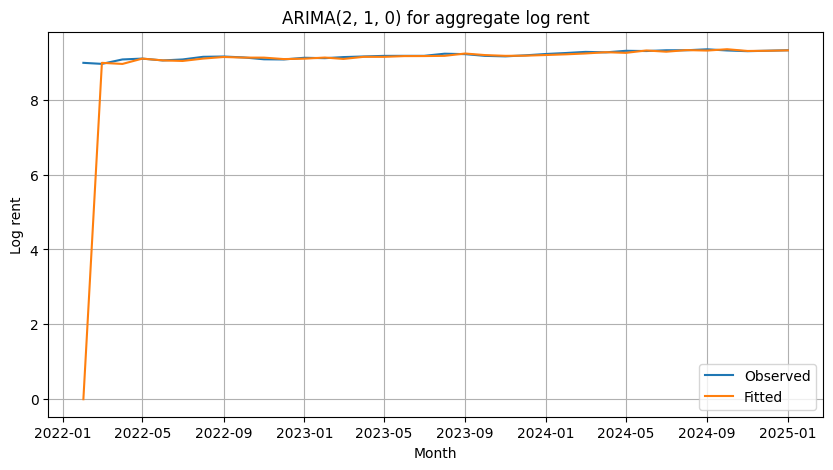

In [7]:
monthly["fitted"] = best_model.predict()

plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["log_rent"], label="Observed")
plt.plot(monthly["month"], monthly["fitted"], label="Fitted")
plt.title(f"ARIMA{best_order} for aggregate log rent")
plt.xlabel("Month")
plt.ylabel("Log rent")
plt.legend()
plt.grid(True)
plt.show()